# Laboratório 4: Classificadores com Scikit Learn

Bem-vindo ao Laboratório 4! Esta semana você utilizará alguns algoritmos implementados na biblioteca Scikit-Learn.

Os tópicos deste laboratório são abordados em [Logística](https://flaviovdf.io/icd-bradesco/14-Logistica/), [KNN](https://flaviovdf.io/icd-bradesco/15-KNN/) e [SKLearn](https://flaviovdf.io/icd-bradesco/16-Pratica/).

**Caso esteja usando collab, lembre-se, para fins didáticos, de desabilitar a assistência por AI nas configurações**


Primeiro, realize as importações executando a célula abaixo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

## Identificação de malignidade em tumores de mama - UCI ML Breast Cancer Wisconsin (Diagnostic)

Neste trabalho você deverá realizar uma comparação entre o k-Nearest Neighbors (KNN) e a Regressão Logística para classificação de pacientes com tumores na mama (maligno = 1 vs benigno = 0). Para isso, usaremos o dataset de câncer de mama de UCI (já embutido no sklearn).

Você não precisa implementar os métodos, já que estão disponíveis na biblioteca scikit-learn da linguagem Python. Se necessário, pode fazer mais importações de bibliotecas.

Esse dataset está na biblioteca sklearn:

In [ ]:
# Importando o dataset
from sklearn.datasets import load_breast_cancer
# Baixando o dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data,columns =[cancer.feature_names])

In [ ]:
# Mostra uma descrição do dataset
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
#Para acessar as labels
cancer.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

##Exercício 1:
Crie uma separação do dataset em conjuntos de treino de validação.

**Dica:** Use a função train_test_split para amostrar e separar treino e validação. Documentação da função [aqui](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)


In [ ]:
X = cancer.data #input
Y = cancer.target #label

X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.2, stratify=Y  # stratify is useful for classification tasks
)

##Exercício 2:
Use a regressão logística implementada no SciKit-Learn para classificar pacientes com e sem câncer.

Para a questão, faça as seguintes tarefas:


*   Com o parametro max_iter=100, realize o treinamento do modelo (.fit)
*   Obtenha a acurácia do modelo nos dados de validação (.score)


Perceba pelo Warning que o modelo não foi capaz de convergir (se ajustar de maneira estável) aos dados de treinamento dentro das 100 iterações.


In [ ]:
clf = LogisticRegression(max_iter=100)
clf.fit(X_train, y_train)
clf.score(X_val, y_val)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.956140350877193

Uma forma de melhorar esse aspecto é normalizar os dados, assim todas as features (colunas) serão dotadas de média 0 e desvio padrão igual a 1. Isso visa tratar problemas gerados pela existência de diferentes escalas nos dados.

##Exercício 3:
Obtenha uma cópia normalizada dos dados.

**Dica:** Utilize StandardScaler de sklearn. Referência [aqui](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn mean/std from training data
X_val_scaled = scaler.transform(X_val)          # Use the same mean/std for validation data

Podemos agora treinar um novo classificador com os dados normalizados. Entretanto há uma forma melhor de se implementar a execução de uma sequência de operações do scikit-learn: os pipelines.

##Exercício 4:
Crie e execute um pipeline para normalizar os dados e, em seguida, ajustar o modelo. Utilize novamente max_iter=100. Após ajustar o modelo obtenha sua acurácia no dataset de validação.

**Dica:** Utilize a função make_pipeline

In [ ]:
log_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=100))
log_model.fit(X_train, y_train)
log_model.score(X_val, y_val)

0.9736842105263158

##Exercício 05:
Use uma KNN para classificar as pacientes com e sem câncer.

Para a questão, faça as seguintes tarefas:

*   Crie um pipeline que normaliza os dados e define o classificador.
*   Realize os experimentos avaliando apenas nos dados separados para validação
*   Escolha e reporte resultados com 3 números de vizinhos diferentes (k)
*   Retorne a acurácia dos modelos nos dados


In [ ]:
K = 3 # mude K aqui

In [ ]:
knn_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=K))
knn_model.fit(X_train, y_train)
knn_model.score(X_val, y_val)

0.956140350877193

##Exercício 6 (Extra):
Obtenha outras métricas para os resultados dos classificadores tais como acurácia, precisão, revocação e f1. Referência [aqui](https://flaviovdf.io/icd-bradesco/16-Pratica/)

**Dica** Essas métricas estão implementadas no sklearn.

In [ ]:
y_pred_log = log_model.predict(X_val)

log_acc = accuracy_score(y_val, y_pred_log)
log_precision = precision_score(y_val, y_pred_log)
log_recall = recall_score(y_val, y_pred_log)
log_f1 = f1_score(y_val, y_pred_log)
print(f"Acc: {log_acc} , Precision: {log_precision} , Recall: {log_recall} , f1: {log_f1}")


y_pred_knn = knn_model.predict(X_val)

knn_acc = accuracy_score(y_val, y_pred_knn)
knn_precision = precision_score(y_val, y_pred_knn)
knn_recall = recall_score(y_val, y_pred_knn)
knn_f1 = f1_score(y_val, y_pred_knn)
print(f"Acc: {knn_acc} , Precision: {knn_precision} , Recall: {knn_recall} , f1: {knn_f1}")

Acc: 0.9736842105263158 , Precision: 0.9726027397260274 , Recall: 0.9861111111111112 , f1: 0.9793103448275862
Acc: 0.956140350877193 , Precision: 0.9466666666666667 , Recall: 0.9861111111111112 , f1: 0.9659863945578231


##Exercício 7 (Extra):
Avalie os modelos utilizando validação cruzada. Referência [aqui](https://medium.com/@edubrazrabello/cross-validation-avaliando-seu-modelo-de-machine-learning-1fb70df15b78) e [aqui](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)

**Dica:** Utilize a função cross_validate. Essa função retorna arrays com metricas apuradas em cada rodada da validação cruzada.

In [ ]:
log_scores = cross_validate(
        log_model, X, Y,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
    )
log_scores

{'fit_time': array([0.00687122, 0.01038837, 0.00657058, 0.00866008, 0.00641704]),
 'score_time': array([0.010602  , 0.01115084, 0.01237965, 0.01123667, 0.01320338]),
 'test_accuracy': array([0.98245614, 0.98245614, 0.97368421, 0.97368421, 0.99115044]),
 'test_precision': array([0.98591549, 0.97260274, 0.96      , 0.97260274, 1.        ]),
 'test_recall': array([0.98591549, 1.        , 1.        , 0.98611111, 0.98591549]),
 'test_f1': array([0.98591549, 0.98611111, 0.97959184, 0.97931034, 0.9929078 ])}

In [ ]:
knn_scores = cross_validate(
        knn_model, X, Y,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
    )
knn_scores

{'fit_time': array([0.00277066, 0.00271749, 0.00362134, 0.00315952, 0.00276613]),
 'score_time': array([0.01700664, 0.01055336, 0.01344609, 0.01217794, 0.01488876]),
 'test_accuracy': array([0.97368421, 0.96491228, 0.98245614, 0.94736842, 0.92920354]),
 'test_precision': array([0.97222222, 0.95890411, 0.97297297, 0.92307692, 0.94366197]),
 'test_recall': array([0.98591549, 0.98591549, 1.        , 1.        , 0.94366197]),
 'test_f1': array([0.97902098, 0.97222222, 0.98630137, 0.96      , 0.94366197])}

##Exercício 8 (Extra):
Avalie o desempenho dos classificadores em diferentes amostras do dataset.

Passos:
*   Criar um loop que se repete N vezes
*   Amostrar uma divisão treino/validação a cada iteração
*   Avaliar o modelo e armazenar as métricas em um vetor
*   Após repetir esse processo N vezes, plotar histogramas das métricas em ambos modelos


O que a distribuição das métricas te diz? Qual modelo é melhor?

In [ ]:
N = 500 # escolha N aqui

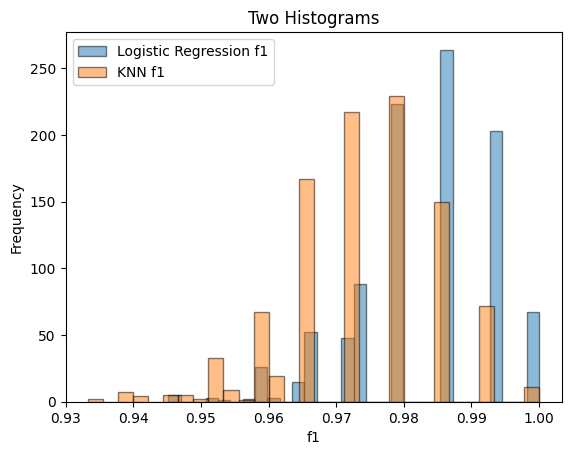

In [ ]:
log_metrics = {'accuracy': [], 'precision':[], 'recall':[], 'f1':[]}
knn_metrics = {'accuracy': [], 'precision':[], 'recall':[], 'f1':[]}



for i in range(N):  # Repeat N times
    X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=i)

    log_model.fit(X_train, y_train)
    knn_model.fit(X_train, y_train)

    y_pred_log = log_model.predict(X_val)
    y_pred_knn = knn_model.predict(X_val)

    log_metrics['accuracy'].append(accuracy_score(y_val, y_pred_log))
    knn_metrics['accuracy'].append(accuracy_score(y_val, y_pred_knn))

    log_metrics['precision'].append(precision_score(y_val, y_pred_log))
    knn_metrics['precision'].append(precision_score(y_val, y_pred_knn))

    log_metrics['recall'].append(recall_score(y_val, y_pred_log))
    knn_metrics['recall'].append(recall_score(y_val, y_pred_knn))

    log_metrics['f1'].append(f1_score(y_val, y_pred_log))
    knn_metrics['f1'].append(f1_score(y_val, y_pred_knn))


# Plot both histograms
plt.hist(log_metrics["f1"],bins=30, label='Logistic Regression f1', edgecolor='black', alpha=0.5)
plt.hist(knn_metrics["f1"],bins=30, label='KNN f1', edgecolor='black', alpha=0.5)

plt.title('f1 Histograms of the models')
plt.xlabel('f1')
plt.ylabel('Frequency')
plt.legend()
plt.show()
